# Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis

plt.style.use("default")

%matplotlib inline

# Load Datasets

In [5]:
ROOT = Path.cwd().parent

DATA = ROOT / "data" / "processed" / "master_dataset.csv"

df = pd.read_csv(DATA)

df["date"] = pd.to_datetime(df["date"])

df.head()

,date,daily_mean_tec,ssn,kp_mean,ap_daily,f107_obs,f107_adj,dst_daily_mean
0,2022-01-01,19.980,48.0,2.416625,12.0,93.9,90.8,-11.125000
1,2022-01-02,19.680,27.0,2.041500,9.0,89.0,86.0,-9.708333
2,2022-01-03,18.256,10.0,2.416625,12.0,84.0,81.3,-10.833333
3,2022-01-04,17.548,10.0,1.083250,5.0,85.5,82.7,-10.083333
4,2022-01-05,15.896,23.0,0.625000,2.0,83.7,81.0,-3.583333


# Dataset Overview

In [8]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

display(df.head())

display(df.info())

Rows: 1096
Columns: 8


,date,daily_mean_tec,ssn,kp_mean,ap_daily,f107_obs,f107_adj,dst_daily_mean
0,2022-01-01,19.980,48.0,2.416625,12.0,93.9,90.8,-11.125000
1,2022-01-02,19.680,27.0,2.041500,9.0,89.0,86.0,-9.708333
2,2022-01-03,18.256,10.0,2.416625,12.0,84.0,81.3,-10.833333
3,2022-01-04,17.548,10.0,1.083250,5.0,85.5,82.7,-10.083333
4,2022-01-05,15.896,23.0,0.625000,2.0,83.7,81.0,-3.583333


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            1096 non-null   datetime64[ns]
 1   daily_mean_tec  1096 non-null   float64       
 2   ssn             1096 non-null   float64       
 3   kp_mean         1096 non-null   float64       
 4   ap_daily        1096 non-null   float64       
 5   f107_obs        1095 non-null   float64       
 6   f107_adj        1095 non-null   float64       
 7   dst_daily_mean  1096 non-null   float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 68.6 KB


None

# Missing Values

In [11]:
df.isna().sum().to_frame("Missing Values")

,Missing Values
date,0
daily_mean_tec,0
ssn,0
kp_mean,0
ap_daily,0
f107_obs,1
f107_adj,1
dst_daily_mean,0


# Duplicate Dates

In [14]:
print("Duplicate dates:", df["date"].duplicated().sum())

print(df["date"].min())
print(df["date"].max())

Duplicate dates: 0
2022-01-01 00:00:00
2024-12-31 00:00:00


# Descriptive Statistics

In [17]:
variables = [
    "daily_mean_tec",
    "ssn",
    "kp_mean",
    "ap_daily",
    "f107_obs",
    "f107_adj",
    "dst_daily_mean",
]

rows = []

for col in variables:

    s = df[col].dropna()

    rows.append({
        "Variable": col,
        "Mean": s.mean(),
        "Median": s.median(),
        "Std": s.std(),
        "Variance": s.var(),
        "Minimum": s.min(),
        "Maximum": s.max(),
        "Skewness": skew(s),
        "Kurtosis": kurtosis(s),
    })

stats = pd.DataFrame(rows)

stats.round(3)

,Variable,Mean,Median,Std,Variance,Minimum,Maximum,Skewness,Kurtosis
0,daily_mean_tec,39.682,39.146,9.692,93.939,14.240,70.804,0.101,-0.263
1,ssn,121.172,118.000,52.072,2711.446,3.000,290.000,0.404,-0.058
2,kp_mean,1.947,1.792,1.001,1.001,0.000,8.375,1.065,2.483
3,ap_daily,10.877,8.000,13.786,190.041,0.000,271.000,8.655,128.186
4,f107_obs,158.625,154.800,40.798,1664.483,83.700,400.700,1.017,2.014
5,f107_adj,158.753,155.300,41.360,1710.623,81.000,412.900,1.039,2.165
6,dst_daily_mean,-11.278,-7.625,20.092,403.672,-286.542,42.833,-4.236,41.369


In [21]:
RESULTS = ROOT / "results"

RESULTS.mkdir(exist_ok=True)

stats.round(3).to_csv(
    RESULTS / "descriptive_statistics.csv",
    index=False,
)
# I used this to save the above table

# Histograms

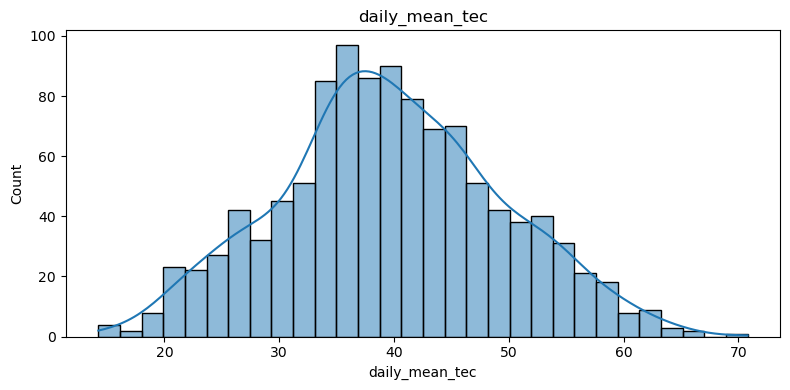

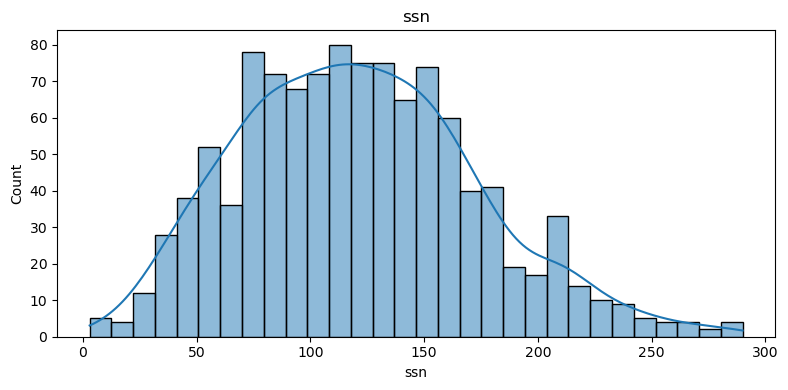

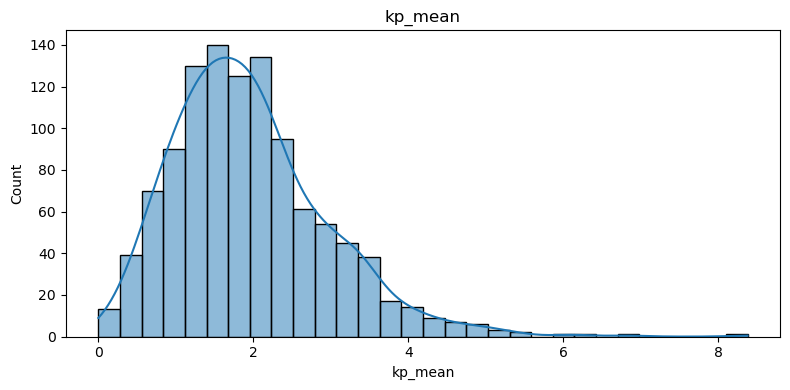

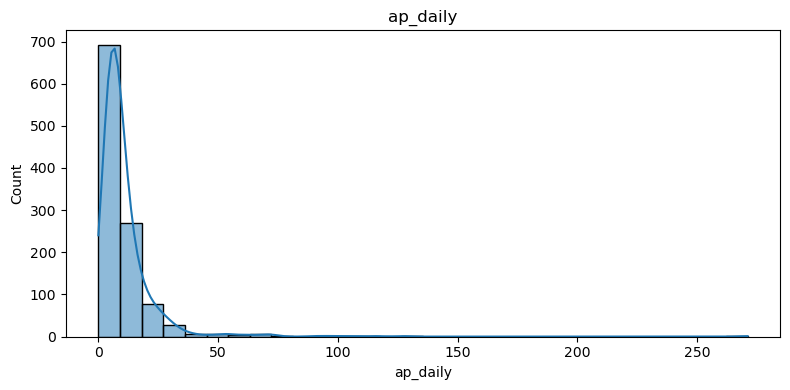

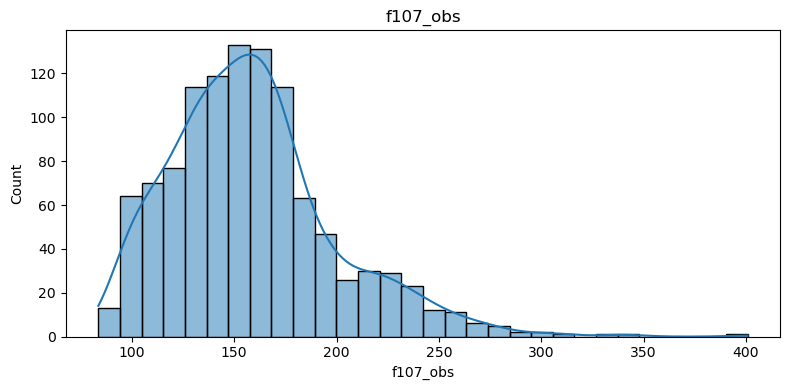

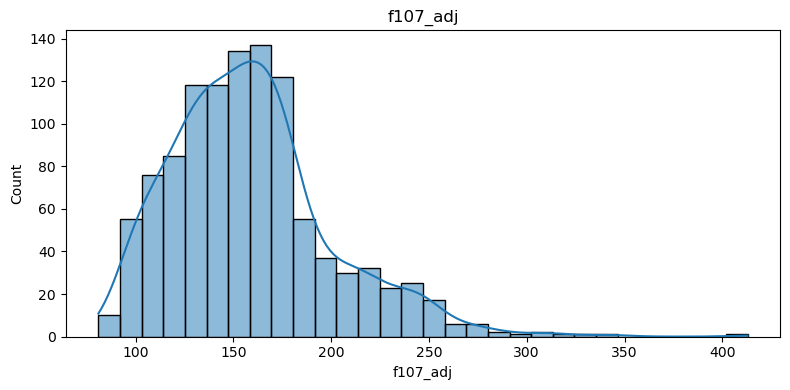

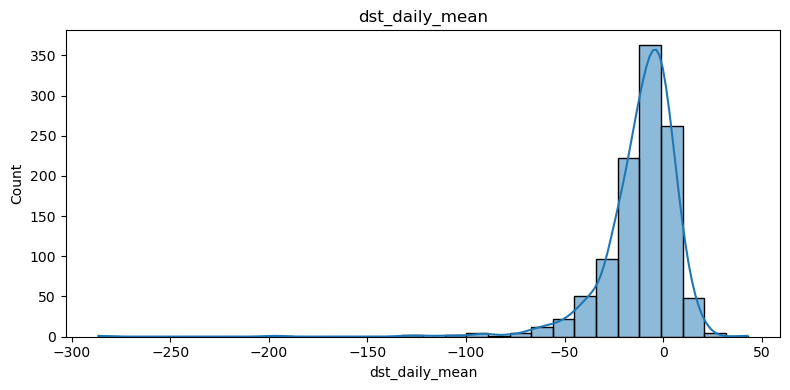

In [24]:
for col in variables:

    plt.figure(figsize=(8,4))

    sns.histplot(df[col], bins=30, kde=True)

    plt.title(col)

    plt.tight_layout()

    plt.show()

# Boxplots

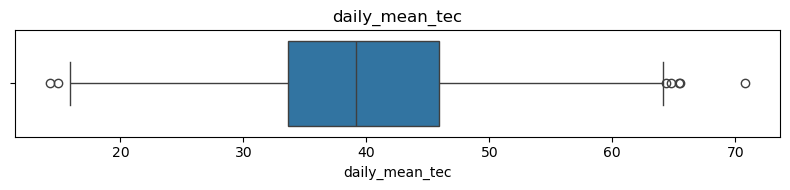

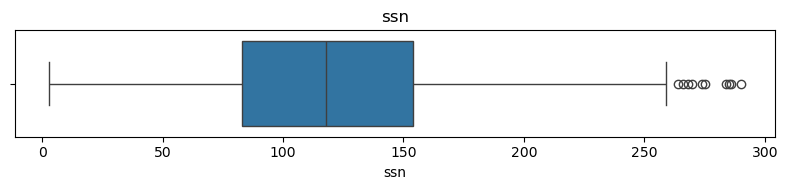

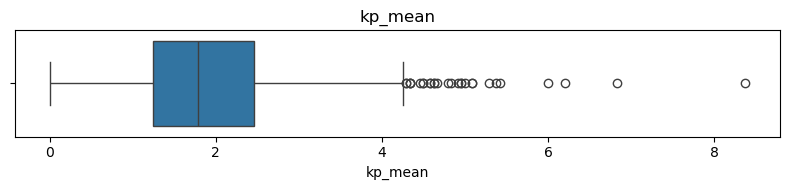

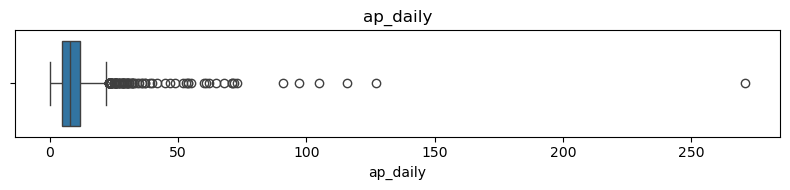

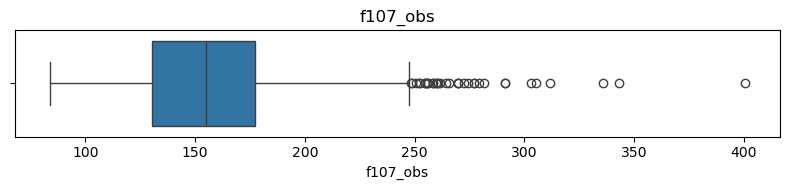

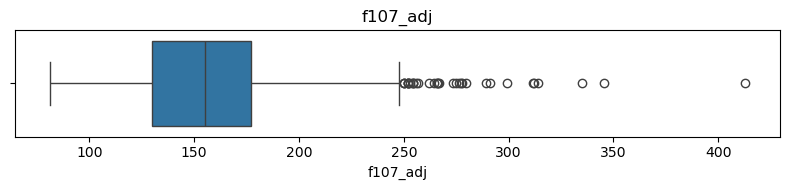

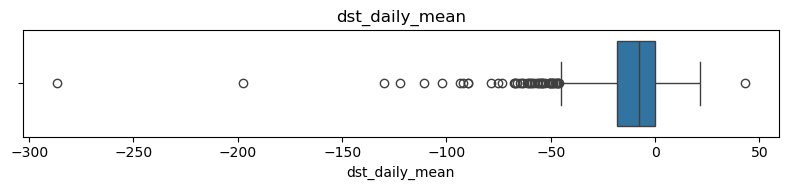

In [27]:
for col in variables:

    plt.figure(figsize=(8,2))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.tight_layout()

    plt.show()

# Tec Time Series

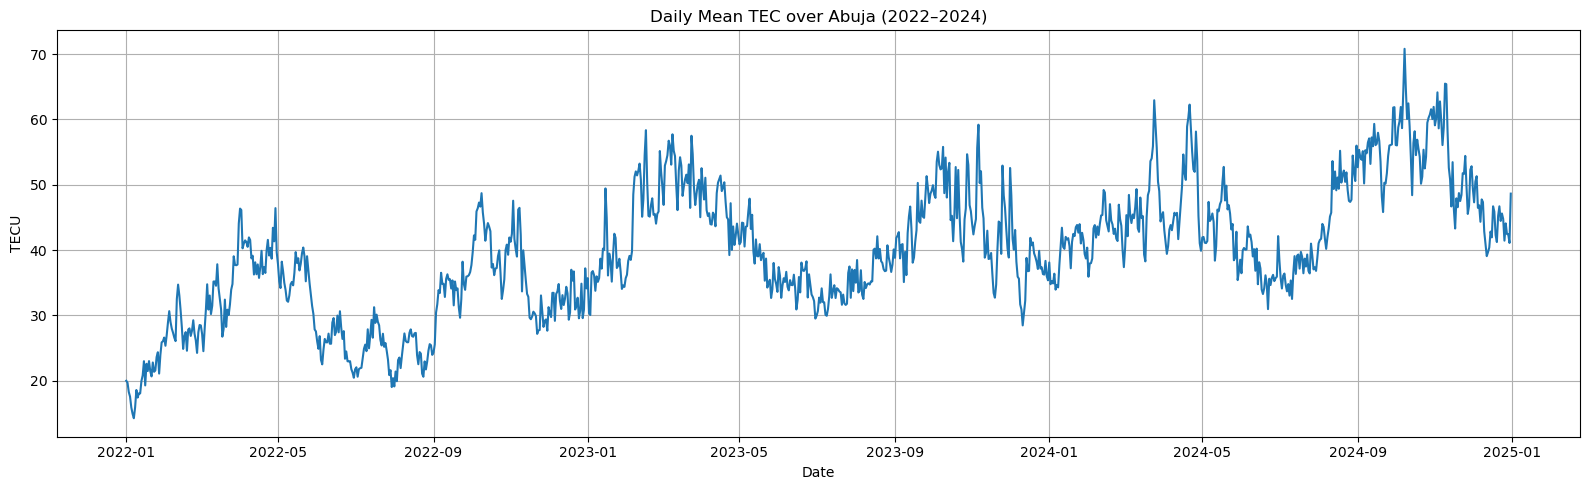

In [31]:
plt.figure(figsize=(16,5))

plt.plot(
    df["date"],
    df["daily_mean_tec"]
)

plt.title("Daily Mean TEC over Abuja (2022–2024)")

plt.xlabel("Date")

plt.ylabel("TECU")

plt.grid(True)

plt.tight_layout()

plt.show()

# Monthly mean

In [34]:
df["month"] = df["date"].dt.month

monthly = (
    df.groupby("month")["daily_mean_tec"]
      .mean()
)

monthly

month
1     32.545806
2     39.492094
3     43.914366
4     44.892667
5     39.522925
6     32.634133
7     31.655871
8     36.421677
9     43.997867
10    49.164344
11    43.799511
12    38.333290
Name: daily_mean_tec, dtype: float64

# Monthly Plot

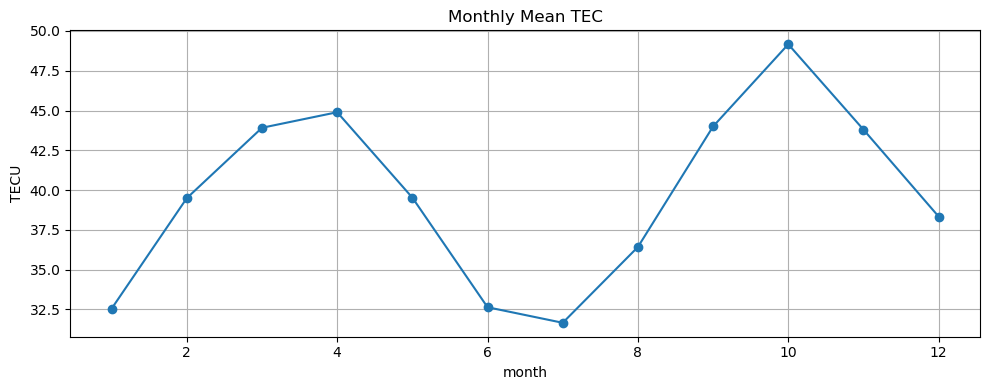

In [37]:
plt.figure(figsize=(10,4))

monthly.plot(marker="o")

plt.title("Monthly Mean TEC")

plt.ylabel("TECU")

plt.grid(True)

plt.tight_layout()

plt.show()

In [41]:
# Add year
df["year"] = df["date"].dt.year

# Annual Comparison

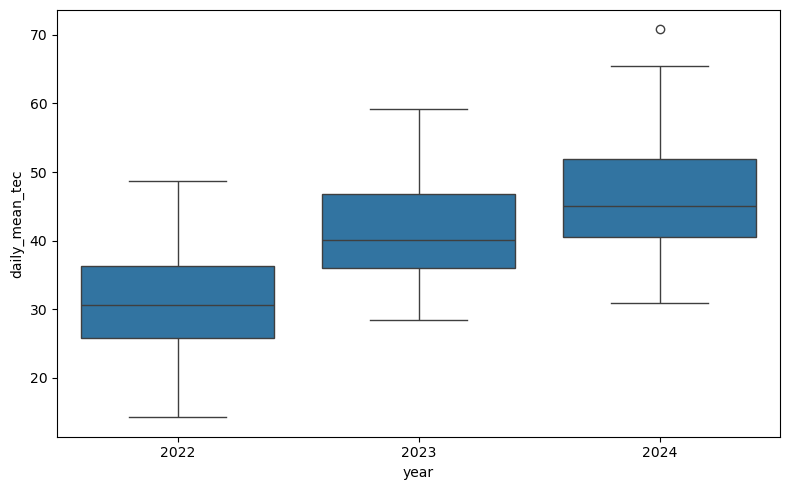

In [44]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="year",
    y="daily_mean_tec"
)

plt.tight_layout()

plt.show()

# Nigerian Seasons

In [47]:
df["season"] = df["month"].map({

    12:"Dry",

    1:"Dry",

    2:"Dry",

    3:"Pre-Rain",

    4:"Pre-Rain",

    5:"Pre-Rain",

    6:"Rainy",

    7:"Rainy",

    8:"Rainy",

    9:"Rainy",

    10:"Post-Rain",

    11:"Post-Rain"

})

# Season Boxplot

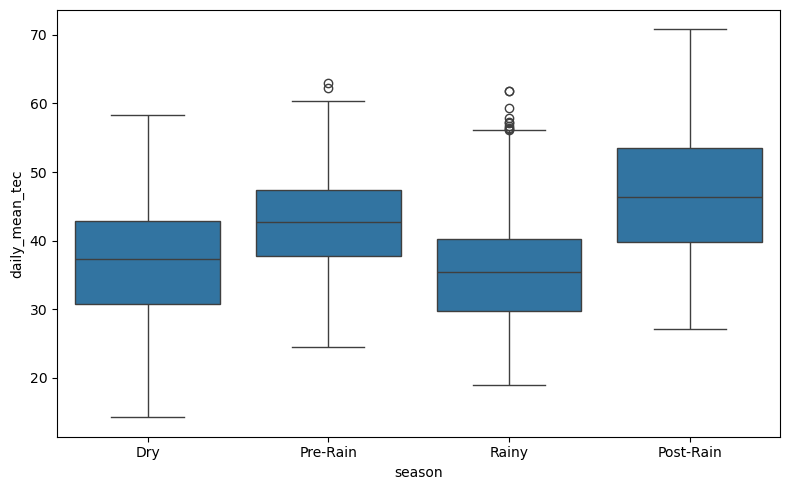

In [50]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="season",
    y="daily_mean_tec"
)

plt.tight_layout()

plt.show()

# Correlation Matrix

In [53]:
corr = df[variables].corr()

corr.round(3)

,daily_mean_tec,ssn,kp_mean,ap_daily,f107_obs,f107_adj,dst_daily_mean
daily_mean_tec,1.000,0.455,0.245,0.192,0.593,0.570,-0.243
ssn,0.455,1.000,0.042,0.060,0.838,0.848,-0.040
kp_mean,0.245,0.042,1.000,0.796,0.078,0.081,-0.678
ap_daily,0.192,0.060,0.796,1.000,0.104,0.107,-0.770
f107_obs,0.593,0.838,0.078,0.104,1.000,0.996,-0.052
f107_adj,0.570,0.848,0.081,0.107,0.996,1.000,-0.050
dst_daily_mean,-0.243,-0.040,-0.678,-0.770,-0.052,-0.050,1.000


# Heatmap

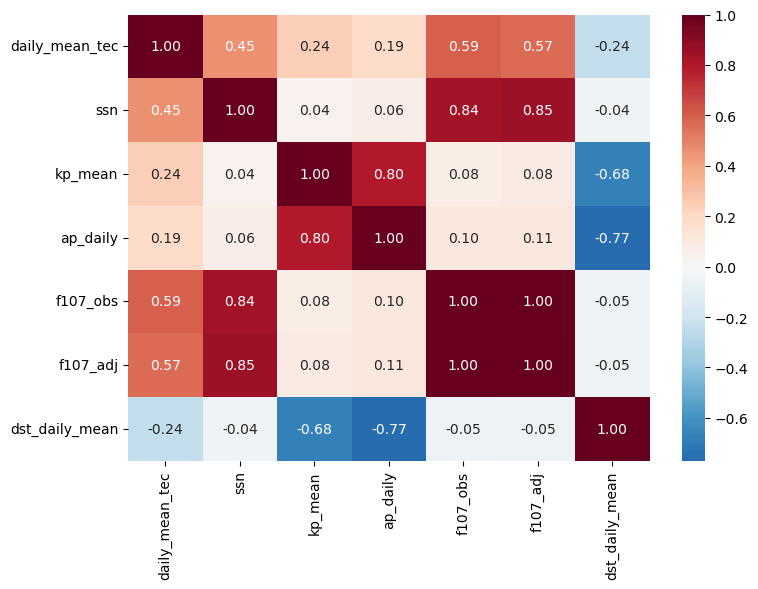

In [56]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f"
)

plt.tight_layout()

plt.show()

# Scatter Plots

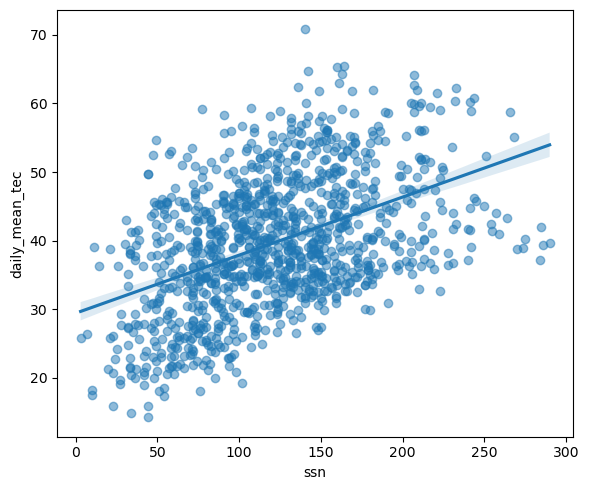

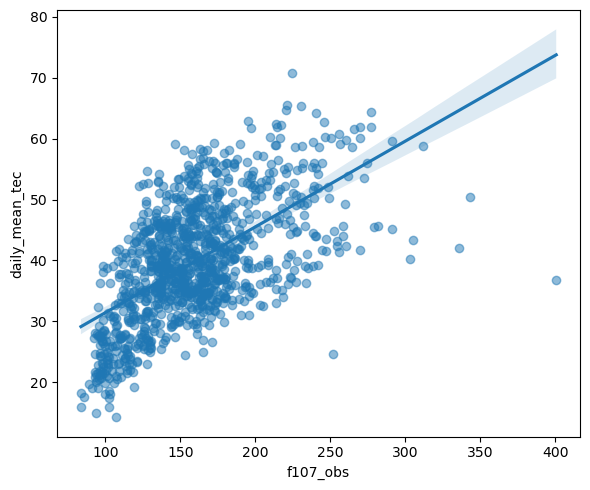

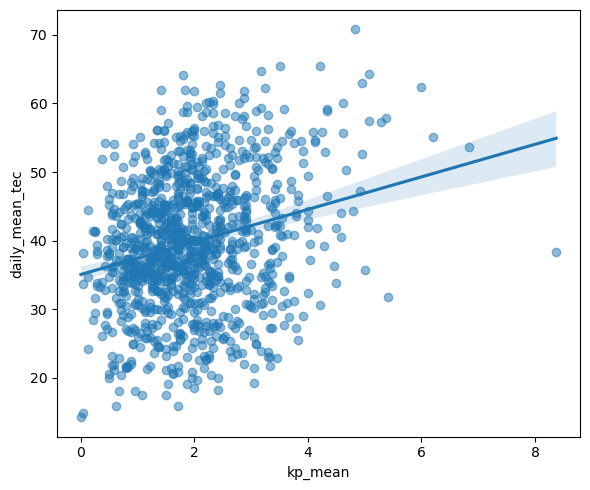

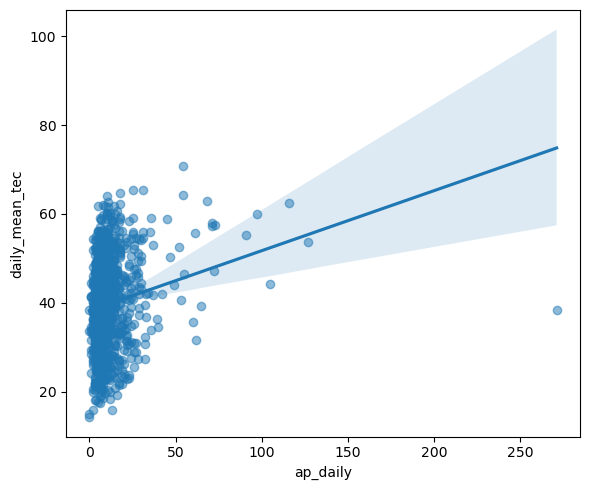

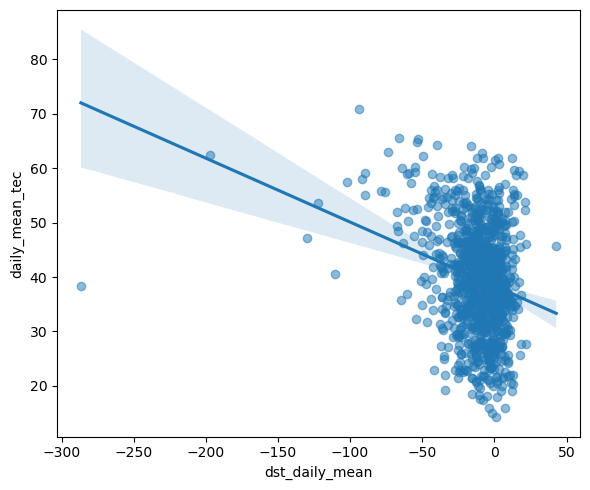

In [59]:
targets = [
    "ssn",
    "f107_obs",
    "kp_mean",
    "ap_daily",
    "dst_daily_mean",
]

for col in targets:

    plt.figure(figsize=(6,5))

    sns.regplot(
        data=df,
        x=col,
        y="daily_mean_tec",
        scatter_kws={"alpha":0.5}
    )

    plt.tight_layout()

    plt.show()